# 자치구 대분류 클러스터링 (초기화 버전)
- 입력 파일: `gu_susi_score_100_by_year.csv`
- 클러스터링 입력: `환경점수`, `안전점수`, `소음점수`, `교통점수_25점`
- `스시점수`는 해석용으로만 사용

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [25]:
data_path = r"C:/Users/yiho1/8ssible-Healing-Seoul-Analysis/프로젝트 HY/gu_susi_score_adjusted_by_year.csv"
df = pd.read_csv(data_path)

COL_GU = "자치구"
COL_YEAR = "연도"
COL_ENV = "환경점수"
COL_SAFE = "안전점수"
COL_NOISE = "소음점수"
COL_TRA = "교통점수"
COL_TOTAL = "스시점수"

feature_cols = [COL_ENV, COL_SAFE, COL_NOISE, COL_TRA]
use_cols = [COL_GU, COL_YEAR] + feature_cols + [COL_TOTAL]
work = df[use_cols].copy()

for c in feature_cols + [COL_TOTAL]:
    work[c] = pd.to_numeric(work[c], errors="coerce")

display(work.head())
print("shape:", work.shape)

,자치구,연도,환경점수,안전점수,소음점수,교통점수,스시점수
0,강남구,2022,11.34,17.20,24.31,20.68,73.53
1,강남구,2023,9.13,16.92,25.00,20.83,71.88
2,강남구,2024,10.67,16.73,24.36,19.49,71.25
3,강동구,2022,15.70,11.70,16.88,13.80,58.08
4,강동구,2023,11.46,12.03,15.96,14.12,53.57


shape: (75, 7)


,k,silhouette
0,2,0.384741
1,3,0.288237
2,4,0.279220
3,5,0.287437
4,6,0.304833


selected_k: 4
silhouette(selected_k): 0.27921991007099084


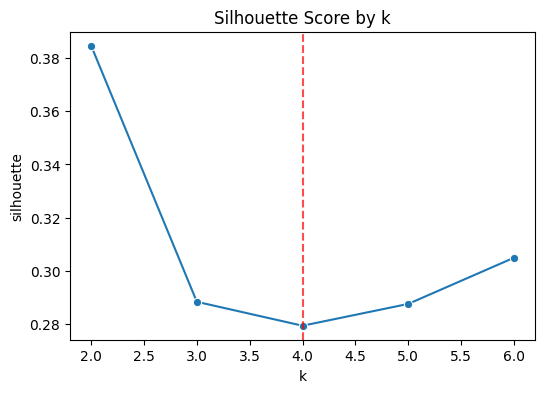

In [26]:
X = work[feature_cols].copy()

imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

k_candidates = range(2, 7)
rows = []
for k in k_candidates:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    rows.append((k, sil))

sil_df = pd.DataFrame(rows, columns=["k", "silhouette"])
display(sil_df)

# ===== 여기 숫자만 바꿔서 실행 =====
K_SELECT = 4  # 4, 5, 6 중 원하는 값으로 변경
# ==============================

if K_SELECT not in sil_df["k"].tolist():
    raise ValueError(f"K_SELECT={K_SELECT} 는 후보 범위 밖입니다. 가능한 값: {sil_df['k'].tolist()}")

best_k = int(K_SELECT)
print("selected_k:", best_k)
print("silhouette(selected_k):", float(sil_df.loc[sil_df['k']==best_k, 'silhouette'].iloc[0]))

plt.figure(figsize=(6, 4))
sns.lineplot(data=sil_df, x="k", y="silhouette", marker="o")
plt.axvline(best_k, color="red", linestyle="--", alpha=0.7)
plt.title("Silhouette Score by k")
plt.show()

In [27]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
work["cluster"] = kmeans.fit_predict(X_scaled)

q = 0.75
work["환경취약"] = work[COL_ENV] >= work[COL_ENV].quantile(q)
work["교통취약"] = work[COL_TRA] >= work[COL_TRA].quantile(q)
work["안전취약"] = work[COL_SAFE] >= work[COL_SAFE].quantile(q)
work["소음취약"] = work[COL_NOISE] >= work[COL_NOISE].quantile(q)

def make_domain_tag(r):
    tags = []
    if r["환경취약"]:
        tags.append("환경취약")
    if r["교통취약"]:
        tags.append("교통취약")
    if r["안전취약"]:
        tags.append("안전취약")
    if r["소음취약"]:
        tags.append("소음취약")
    return ", ".join(tags) if tags else "전반양호"

work["기본태그"] = work.apply(make_domain_tag, axis=1)

profile = work.groupby("cluster")[feature_cols].mean().round(2)
global_mean = work[feature_cols].mean()
name_map = {COL_ENV: "환경", COL_TRA: "교통", COL_SAFE: "안전", COL_NOISE: "소음"}

def label_cluster(row):
    weak = [name_map[c] for c in feature_cols if row[c] >= global_mean[c]]
    if not weak:
        return "전반양호형"
    return "+".join(weak[:2]) + " 취약형"

cluster_label_map = profile.apply(label_cluster, axis=1).to_dict()
work["cluster_label"] = work["cluster"].map(cluster_label_map)

display(profile)
display(work[[COL_GU, COL_YEAR, COL_TOTAL, "cluster", "cluster_label", "기본태그"]].sort_values([COL_YEAR, COL_GU]).head(75))

,환경점수,안전점수,소음점수,교통점수
cluster,,,,
0,12.53,18.67,19.95,19.18
1,12.74,12.88,14.93,13.53
2,12.03,12.69,19.53,15.57
3,15.13,12.55,16.26,13.42


,자치구,연도,스시점수,cluster,cluster_label,기본태그
0,강남구,2022,73.53,0,안전+소음 취약형,"교통취약, 안전취약, 소음취약"
3,강동구,2022,58.08,3,환경 취약형,환경취약
6,강북구,2022,60.18,3,환경 취약형,환경취약
9,강서구,2022,56.77,2,소음+교통 취약형,전반양호
12,관악구,2022,60.45,3,환경 취약형,환경취약
...,...,...,...,...,...,...
62,용산구,2024,73.24,0,안전+소음 취약형,"교통취약, 안전취약"
65,은평구,2024,58.16,2,소음+교통 취약형,소음취약
68,종로구,2024,71.47,0,안전+소음 취약형,"안전취약, 소음취약"
71,중구,2024,72.43,0,안전+소음 취약형,"교통취약, 안전취약"


In [28]:
out_path = r"C:/Users/yiho1/Documents/Codex/2026-05-08/new-chat/domain_cluster_init_result.csv"
out_profile = r"C:/Users/yiho1/Documents/Codex/2026-05-08/new-chat/domain_cluster_profile.csv"

work.to_csv(out_path, index=False, encoding="utf-8-sig")
profile_out = profile.copy()
profile_out["cluster_label"] = profile_out.index.map(cluster_label_map)
profile_out.to_csv(out_profile, encoding="utf-8-sig")

print("saved:", out_path)
print("saved:", out_profile)

saved: C:/Users/yiho1/Documents/Codex/2026-05-08/new-chat/domain_cluster_init_result.csv
saved: C:/Users/yiho1/Documents/Codex/2026-05-08/new-chat/domain_cluster_profile.csv


In [29]:
# 연도별/자치구별 결과 보기
# 1) 전체 보기 (연도 -> 자치구 정렬)
view_cols = [COL_YEAR, COL_GU, COL_ENV, COL_SAFE, COL_NOISE, COL_TRA, COL_TOTAL, "cluster", "cluster_label", "기본태그"]
result_view = work[view_cols].sort_values([COL_YEAR, COL_GU]).reset_index(drop=True)
display(result_view)

# 2) 특정 연도만 보기 (원하는 값으로 바꿔서 실행)
target_year = 2023
display(result_view[result_view[COL_YEAR] == target_year].reset_index(drop=True))

# 3) 특정 자치구만 보기 (원하는 구로 바꿔서 실행)
target_gu = "강남구"
display(result_view[result_view[COL_GU] == target_gu].sort_values(COL_YEAR).reset_index(drop=True))

,연도,자치구,환경점수,안전점수,소음점수,교통점수,스시점수,cluster,cluster_label,기본태그
0,2022,강남구,11.34,17.20,24.31,20.68,73.53,0,안전+소음 취약형,"교통취약, 안전취약, 소음취약"
1,2022,강동구,15.70,11.70,16.88,13.80,58.08,3,환경 취약형,환경취약
2,2022,강북구,15.96,13.06,16.65,14.51,60.18,3,환경 취약형,환경취약
3,2022,강서구,11.78,11.58,19.05,14.36,56.77,2,소음+교통 취약형,전반양호
4,2022,관악구,15.20,13.92,15.83,15.50,60.45,3,환경 취약형,환경취약
...,...,...,...,...,...,...,...,...,...,...
70,2024,용산구,14.10,20.59,18.75,19.80,73.24,0,안전+소음 취약형,"교통취약, 안전취약"
71,2024,은평구,11.54,12.42,20.52,13.68,58.16,2,소음+교통 취약형,소음취약
72,2024,종로구,13.59,20.22,20.20,17.46,71.47,0,안전+소음 취약형,"안전취약, 소음취약"
73,2024,중구,11.93,25.00,16.47,19.03,72.43,0,안전+소음 취약형,"교통취약, 안전취약"


,연도,자치구,환경점수,안전점수,소음점수,교통점수,스시점수,cluster,cluster_label,기본태그
0,2023,강남구,9.13,16.92,25.00,20.83,71.88,0,안전+소음 취약형,"교통취약, 안전취약, 소음취약"
1,2023,강동구,11.46,12.03,15.96,14.12,53.57,1,전반양호형,전반양호
2,2023,강북구,13.76,13.00,14.49,14.72,55.97,1,전반양호형,전반양호
3,2023,강서구,9.31,11.62,18.89,16.58,56.40,2,소음+교통 취약형,전반양호
4,2023,관악구,11.94,14.08,14.76,15.94,56.72,1,전반양호형,전반양호
5,2023,광진구,11.99,14.42,14.95,15.19,56.55,1,전반양호형,전반양호
6,2023,구로구,11.93,14.08,15.85,13.81,55.67,1,전반양호형,전반양호
7,2023,금천구,12.32,14.14,14.57,8.72,49.75,1,전반양호형,전반양호
8,2023,노원구,11.10,12.16,13.96,13.94,51.16,1,전반양호형,전반양호
9,2023,도봉구,12.85,12.09,14.48,12.06,51.48,1,전반양호형,전반양호


,연도,자치구,환경점수,안전점수,소음점수,교통점수,스시점수,cluster,cluster_label,기본태그
0,2022,강남구,11.34,17.20,24.31,20.68,73.53,0,안전+소음 취약형,"교통취약, 안전취약, 소음취약"
1,2023,강남구,9.13,16.92,25.00,20.83,71.88,0,안전+소음 취약형,"교통취약, 안전취약, 소음취약"
2,2024,강남구,10.67,16.73,24.36,19.49,71.25,0,안전+소음 취약형,"교통취약, 안전취약, 소음취약"


## 대안 실험: k=4 + z-score 기반 군집 라벨링`n기존 결과는 유지하고, 아래 셀로 대안 버전을 별도로 계산해 비교합니다.

In [30]:
# ===== 대안 버전 (기존 work 유지) =====
# 1) k를 고정해 다시 군집화
k_alt = 4

X = work[feature_cols].copy()
imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

kmeans_alt = KMeans(n_clusters=k_alt, random_state=42, n_init=20)
work_alt = work.copy()
work_alt["cluster_alt"] = kmeans_alt.fit_predict(X_scaled)

# 2) 항상 top2 축 라벨링 (전반양호형 최소화)
profile_alt = work_alt.groupby("cluster_alt")[feature_cols].mean()
mu = work_alt[feature_cols].mean()
sd = work_alt[feature_cols].std(ddof=0).replace(0, 1e-9)
name_map = {COL_ENV:"환경", COL_TRA:"교통", COL_SAFE:"안전", COL_NOISE:"소음"}

def label_cluster_v3(row):
    z = ((row - mu) / sd).sort_values(ascending=False)
    top2 = list(z.index[:2])
    return "+".join(name_map[c] for c in top2) + " 취약형"

cluster_label_map_alt = {idx: label_cluster_v3(r) for idx, r in profile_alt.iterrows()}
work_alt["cluster_label_alt"] = work_alt["cluster_alt"].map(cluster_label_map_alt)

# 3) 기존 기본태그도 함께 비교
display(profile_alt.round(2))

compare_cols = [COL_YEAR, COL_GU, COL_TOTAL, "cluster_alt", "cluster_label_alt", "기본태그"]
display(work_alt[compare_cols].sort_values([COL_YEAR, COL_GU]).reset_index(drop=True))

print("cluster counts (alt):")
print(work_alt["cluster_alt"].value_counts().sort_index())

# 필요 시 저장
out_alt = r"C:/Users/yiho1/Documents/Codex/2026-05-08/new-chat/domain_cluster_alt_k5_top2label.csv"
work_alt.to_csv(out_alt, index=False, encoding="utf-8-sig")
print("saved:", out_alt)

,환경점수,안전점수,소음점수,교통점수
cluster_alt,,,,
0,12.53,18.67,19.95,19.18
1,12.74,12.88,14.93,13.53
2,12.03,12.69,19.53,15.57
3,15.13,12.55,16.26,13.42


,연도,자치구,스시점수,cluster_alt,cluster_label_alt,기본태그
0,2022,강남구,73.53,0,안전+교통 취약형,"교통취약, 안전취약, 소음취약"
1,2022,강동구,58.08,3,환경+소음 취약형,환경취약
2,2022,강북구,60.18,3,환경+소음 취약형,환경취약
3,2022,강서구,56.77,2,소음+교통 취약형,전반양호
4,2022,관악구,60.45,3,환경+소음 취약형,환경취약
...,...,...,...,...,...,...
70,2024,용산구,73.24,0,안전+교통 취약형,"교통취약, 안전취약"
71,2024,은평구,58.16,2,소음+교통 취약형,소음취약
72,2024,종로구,71.47,0,안전+교통 취약형,"안전취약, 소음취약"
73,2024,중구,72.43,0,안전+교통 취약형,"교통취약, 안전취약"


cluster counts (alt):
cluster_alt
0    20
1    23
2    15
3    17
Name: count, dtype: int64
saved: C:/Users/yiho1/Documents/Codex/2026-05-08/new-chat/domain_cluster_alt_k5_top2label.csv


In [31]:
# 마지막 셀 수정본
# 1) 단일최고스트레스태그 -> 기본태그
# 2) 기존 기본태그 컬럼 삭제
# 3) 클러스터 라벨은 항상 2개 축(top2)으로 강제
# 4) 기존 cluster/cluster_label 컬럼은 여기서 즉시 제거

def apply_final_rules(df_obj, cluster_col, cluster_label_col):
    out = df_obj.copy()

    # 기존 기본태그 삭제
    if "기본태그" in out.columns:
        out = out.drop(columns=["기본태그"])

    # 기본태그: 4대 점수 중 가장 높은 축 1개
    top_col = out[[COL_ENV, COL_SAFE, COL_NOISE, COL_TRA]].idxmax(axis=1)
    top_map = {
        COL_ENV: "환경취약",
        COL_SAFE: "안전취약",
        COL_NOISE: "소음취약",
        COL_TRA: "교통취약",
    }
    out["기본태그"] = top_col.map(top_map)

    # 유형 컬럼
    q = 0.75
    out["환경취약"] = out[COL_ENV] >= out[COL_ENV].quantile(q)
    out["교통취약"] = out[COL_TRA] >= out[COL_TRA].quantile(q)
    out["안전취약"] = out[COL_SAFE] >= out[COL_SAFE].quantile(q)
    out["소음취약"] = out[COL_NOISE] >= out[COL_NOISE].quantile(q)

    weak_cnt = out[["환경취약", "교통취약", "안전취약", "소음취약"]].sum(axis=1)
    def classify_type(n):
        if n == 0:
            return "전반안정형"
        if n == 1:
            return "한가지뚜렷형"
        return "종합위험형"
    out["기본태그_유형"] = weak_cnt.map(classify_type)

    # 클러스터 라벨: 항상 top2 축으로 강제
    profile = out.groupby(cluster_col)[[COL_ENV, COL_SAFE, COL_NOISE, COL_TRA]].mean()
    mu = out[[COL_ENV, COL_SAFE, COL_NOISE, COL_TRA]].mean()
    sd = out[[COL_ENV, COL_SAFE, COL_NOISE, COL_TRA]].std(ddof=0).replace(0, 1e-9)
    name_map = {COL_ENV: "환경", COL_SAFE: "안전", COL_NOISE: "소음", COL_TRA: "교통"}

    def label_top2(row):
        z = ((row - mu) / sd).sort_values(ascending=False)
        top2 = list(z.index[:2])
        return "+".join(name_map[c] for c in top2) + " 취약형"

    label_map = {idx: label_top2(r) for idx, r in profile.iterrows()}
    out[cluster_label_col] = out[cluster_col].map(label_map)

    return out

# 기존 결과(work)
work = apply_final_rules(work, "cluster", "cluster_label")
# 기존 cluster 컬럼 제거 (old 결과 숨김)
for c in ["cluster", "cluster_label"]:
    if c in work.columns:
        work = work.drop(columns=[c])

print("===== 기존 결과(work) =====")
show_cols_work = [COL_YEAR, COL_GU, COL_TOTAL, "기본태그", "기본태그_유형"]
display(work[show_cols_work].sort_values([COL_YEAR, COL_TOTAL], ascending=[True, False]).reset_index(drop=True).head(80))

# 대안 결과(work_alt)
if "work_alt" in globals():
    work_alt = apply_final_rules(work_alt, "cluster_alt", "cluster_label_alt")
    # 혹시 남아있을 수 있는 old 컬럼 제거
    for c in ["cluster", "cluster_label"]:
        if c in work_alt.columns:
            work_alt = work_alt.drop(columns=[c])

    print("===== 대안 결과(work_alt) =====")
    show_cols_alt = [COL_YEAR, COL_GU, COL_TOTAL, "기본태그", "기본태그_유형", "cluster_alt", "cluster_label_alt"]
    display(work_alt[show_cols_alt].sort_values([COL_YEAR, COL_TOTAL], ascending=[True, False]).reset_index(drop=True).head(80))
else:
    print("work_alt가 아직 없습니다. 대안 실험 셀 실행 후 다시 실행하세요.")

===== 기존 결과(work) =====


,연도,자치구,스시점수,기본태그,기본태그_유형
0,2022,중구,78.42,안전취약,종합위험형
1,2022,강남구,73.53,소음취약,종합위험형
2,2022,종로구,73.49,안전취약,종합위험형
3,2022,용산구,69.87,소음취약,종합위험형
4,2022,마포구,69.08,소음취약,종합위험형
...,...,...,...,...,...
70,2024,동작구,54.34,교통취약,전반안정형
71,2024,도봉구,53.29,환경취약,한가지뚜렷형
72,2024,양천구,52.85,소음취약,전반안정형
73,2024,노원구,51.65,교통취약,전반안정형


===== 대안 결과(work_alt) =====


,연도,자치구,스시점수,기본태그,기본태그_유형,cluster_alt,cluster_label_alt
0,2022,중구,78.42,안전취약,종합위험형,0,안전+교통 취약형
1,2022,강남구,73.53,소음취약,종합위험형,0,안전+교통 취약형
2,2022,종로구,73.49,안전취약,종합위험형,0,안전+교통 취약형
3,2022,용산구,69.87,소음취약,종합위험형,0,안전+교통 취약형
4,2022,마포구,69.08,소음취약,종합위험형,0,안전+교통 취약형
...,...,...,...,...,...,...,...
70,2024,동작구,54.34,교통취약,전반안정형,1,환경+안전 취약형
71,2024,도봉구,53.29,환경취약,한가지뚜렷형,3,환경+소음 취약형
72,2024,양천구,52.85,소음취약,전반안정형,1,환경+안전 취약형
73,2024,노원구,51.65,교통취약,전반안정형,1,환경+안전 취약형


In [32]:
# ===== CSV 저장 코드만 추가 (원본 함수/형식 유지) =====

# 기존 결과 저장
cols_work = [COL_YEAR, COL_GU, COL_ENV, COL_SAFE, COL_NOISE, COL_TRA, COL_TOTAL]
for c in ["기본태그", "기본태그_유형", "cluster", "cluster_label", "cluster_alt", "cluster_label_alt"]:
    if c in work.columns:
        cols_work.append(c)

view_work = (
    work[cols_work]
    .copy()
    .sort_values([COL_YEAR, COL_TOTAL], ascending=[True, False])
    .reset_index(drop=True)
)


view_work.to_csv("work_ranked_by_year.csv", index=False, encoding="utf-8-sig")
print("[저장 완료]")

# 대안 결과 저장 (있을 때만)
if "work_alt" in globals():
    cols_alt = [COL_YEAR, COL_GU, COL_ENV, COL_SAFE, COL_NOISE, COL_TRA, COL_TOTAL]
    for c in ["기본태그", "기본태그_유형", "cluster", "cluster_label", "cluster_alt", "cluster_label_alt"]:
        if c in work_alt.columns:
            cols_alt.append(c)

    view_work_alt = (
        work_alt[cols_alt]
        .copy()
        .sort_values([COL_YEAR, COL_TOTAL], ascending=[True, False])
        .reset_index(drop=True)
    )

    
    view_work_alt.to_csv("work_alt_ranked_by_year.csv", index=False, encoding="utf-8-sig")
    print("[저장 완료]")
else:
    print("work_alt가 아직 없습니다. 대안 실험 셀 실행 후 다시 저장하세요.")

display(view_work)
display(view_work_alt)

[저장 완료]
[저장 완료]


,연도,자치구,환경점수,안전점수,소음점수,교통점수,스시점수,기본태그,기본태그_유형
0,2022,중구,13.25,25.00,21.03,19.14,78.42,안전취약,종합위험형
1,2022,강남구,11.34,17.20,24.31,20.68,73.53,소음취약,종합위험형
2,2022,종로구,15.61,21.07,18.95,17.86,73.49,안전취약,종합위험형
3,2022,용산구,14.25,18.01,18.84,18.77,69.87,소음취약,종합위험형
4,2022,마포구,14.46,16.16,19.28,19.18,69.08,소음취약,종합위험형
...,...,...,...,...,...,...,...,...,...
70,2024,동작구,13.68,12.43,13.92,14.31,54.34,교통취약,전반안정형
71,2024,도봉구,15.07,11.75,14.42,12.05,53.29,환경취약,한가지뚜렷형
72,2024,양천구,12.65,12.46,15.42,12.32,52.85,소음취약,전반안정형
73,2024,노원구,11.93,11.85,13.84,14.03,51.65,교통취약,전반안정형


,연도,자치구,환경점수,안전점수,소음점수,교통점수,스시점수,기본태그,기본태그_유형,cluster_alt,cluster_label_alt
0,2022,중구,13.25,25.00,21.03,19.14,78.42,안전취약,종합위험형,0,안전+교통 취약형
1,2022,강남구,11.34,17.20,24.31,20.68,73.53,소음취약,종합위험형,0,안전+교통 취약형
2,2022,종로구,15.61,21.07,18.95,17.86,73.49,안전취약,종합위험형,0,안전+교통 취약형
3,2022,용산구,14.25,18.01,18.84,18.77,69.87,소음취약,종합위험형,0,안전+교통 취약형
4,2022,마포구,14.46,16.16,19.28,19.18,69.08,소음취약,종합위험형,0,안전+교통 취약형
...,...,...,...,...,...,...,...,...,...,...,...
70,2024,동작구,13.68,12.43,13.92,14.31,54.34,교통취약,전반안정형,1,환경+안전 취약형
71,2024,도봉구,15.07,11.75,14.42,12.05,53.29,환경취약,한가지뚜렷형,3,환경+소음 취약형
72,2024,양천구,12.65,12.46,15.42,12.32,52.85,소음취약,전반안정형,1,환경+안전 취약형
73,2024,노원구,11.93,11.85,13.84,14.03,51.65,교통취약,전반안정형,1,환경+안전 취약형


## 클러스터 수(k) 검증 가이드 (3~6)
이 섹션은 `억지 군집`을 줄이고, 데이터에 맞는 k를 고르기 위한 검증 단계입니다.

핵심 질문:
1. 군집이 서로 잘 분리되는가?
2. 군집 내부가 충분히 응집되어 있는가?
3. 군집 크기가 지나치게 한쪽으로 쏠리지 않는가?
4. 실제로 해석 가능한 유형(라벨)인가?

### 1) 왜 검증이 필요한가?
- k를 임의로 정하면 의미 없는 그룹이 생길 수 있습니다.
- 지표를 함께 보고 고르면 결과의 신뢰도와 설명력이 올라갑니다.

이번에 볼 지표:
- Silhouette: 높을수록 좋음 (분리+응집)
- Inertia(Elbow): 낮을수록 좋음 (단, elbow 지점이 중요)
- Davies-Bouldin: 낮을수록 좋음
- Calinski-Harabasz: 높을수록 좋음
- Balance ratio: 높을수록 좋음 (군집 크기 균형)

### 2) 검증용 입력 데이터 준비
- 클러스터링 입력은 대분류 4개 점수만 사용합니다.
- 결측치 중앙값 대체 후 표준화합니다.

In [33]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

X_eval = work[[COL_ENV, COL_SAFE, COL_NOISE, COL_TRA]].copy()
imp_eval = SimpleImputer(strategy="median")
X_eval_imp = imp_eval.fit_transform(X_eval)
scaler_eval = StandardScaler()
X_eval_scaled = scaler_eval.fit_transform(X_eval_imp)

print("검증 입력 shape:", X_eval_scaled.shape)

검증 입력 shape: (75, 4)


### 3) k=3~6 전부 계산
- 같은 전처리 데이터로 k만 바꿔 반복 계산합니다.
- 각 k에 대해 정량 지표를 모두 수집합니다.

In [34]:
k_range = range(3, 7)
rows = []
profiles = {}

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=30)
    labels = km.fit_predict(X_eval_scaled)

    sil = silhouette_score(X_eval_scaled, labels)
    dbi = davies_bouldin_score(X_eval_scaled, labels)
    chi = calinski_harabasz_score(X_eval_scaled, labels)
    inertia = km.inertia_

    counts = pd.Series(labels).value_counts().sort_index()
    min_size = int(counts.min())
    max_size = int(counts.max())
    balance_ratio = min_size / max_size

    centers = km.cluster_centers_
    dists = []
    for i in range(len(centers)):
        for j in range(i+1, len(centers)):
            dists.append(np.linalg.norm(centers[i] - centers[j]))
    center_dist_mean = float(np.mean(dists)) if dists else np.nan

    rows.append({
        "k": k,
        "silhouette": sil,
        "davies_bouldin": dbi,
        "calinski_harabasz": chi,
        "inertia": inertia,
        "min_cluster_size": min_size,
        "max_cluster_size": max_size,
        "balance_ratio": balance_ratio,
        "center_dist_mean": center_dist_mean,
    })

    tmp = work.copy()
    tmp["cluster_tmp"] = labels
    profiles[k] = tmp.groupby("cluster_tmp")[[COL_ENV, COL_SAFE, COL_NOISE, COL_TRA, COL_TOTAL]].mean().round(2)

eval_df = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
display(eval_df)

,k,silhouette,davies_bouldin,calinski_harabasz,inertia,min_cluster_size,max_cluster_size,balance_ratio,center_dist_mean
0,3,0.288237,1.255101,43.511015,135.830237,21,31,0.677419,2.515856
1,4,0.279220,1.160963,38.392042,114.407796,15,23,0.652174,2.453540
2,5,0.297110,1.063411,37.119663,96.119232,4,23,0.173913,2.847284
3,6,0.304833,1.035006,36.844225,81.746735,3,22,0.136364,2.893790


## k 검증 결과 해석

### 1) 지표별 의미
- `silhouette` : 높을수록 좋음 (군집 간 분리 + 군집 내 응집)
- `davies_bouldin` : 낮을수록 좋음 (군집 간 분리가 잘 되고 군집 내부가 조밀)
- `calinski_harabasz` : 높을수록 좋음 (군집 간 분산 대비 군집 내 분산이 작음)
- `inertia` : 낮을수록 좋음 (엘보우 지점 확인용)
- `min_cluster_size`, `max_cluster_size` : 가장 작은/큰 군집 크기
- `balance_ratio` : `min/max`, 1에 가까울수록 군집 균형이 좋음
- `center_dist_mean` : 군집 중심 간 평균 거리 (높을수록 분리 경향)

### 2) 이번 결과 요약 (k=3~6)
- `silhouette`는 k가 커질수록 개선됨 (`k=6` 최고)
- `davies_bouldin`도 k가 커질수록 개선됨 (`k=6` 최저)
- `calinski_harabasz`는 `k=3`이 가장 높음
- `inertia`는 k 증가에 따라 자연스럽게 감소 (뚜렷한 단일 elbow는 약함)
- `balance_ratio`는 `k=3(0.677)`, `k=4(0.652)`는 양호
- `k=5(0.174)`, `k=6(0.136)`은 군집 쏠림이 큼 (아주 작은 군집 발생)

### 3) 해석 및 선택
- `k=5,6`은 분리 지표는 좋지만 군집 불균형이 심해 실무 운영/해석 리스크가 큼
- `k=3,4`는 군집 균형이 상대적으로 안정적
- **최종 추천: `k=4`**
  - `k=3` 대비 유형 다양성 확보
  - `k=5,6` 대비 군집 균형/설명 가능성이 더 좋음


### 4) 종합 점수로 추천 k 만들기
- 지표마다 방향이 달라서 min-max 정규화 후 가중합합니다.
- 이 값은 참고용이며, 최종 선택은 해석 가능성과 함께 판단합니다.

In [35]:
def minmax(s, reverse=False):
    s = s.astype(float)
    mn, mx = s.min(), s.max()
    if mx == mn:
        out = pd.Series([0.5]*len(s), index=s.index)
    else:
        out = (s - mn) / (mx - mn)
    return 1 - out if reverse else out

eval_df["score_sil"] = minmax(eval_df["silhouette"])
eval_df["score_dbi"] = minmax(eval_df["davies_bouldin"], reverse=True)
eval_df["score_chi"] = minmax(eval_df["calinski_harabasz"])
eval_df["score_bal"] = minmax(eval_df["balance_ratio"])
eval_df["score_sep"] = minmax(eval_df["center_dist_mean"])

eval_df["composite"] = (
    0.35*eval_df["score_sil"] +
    0.20*eval_df["score_dbi"] +
    0.20*eval_df["score_chi"] +
    0.15*eval_df["score_bal"] +
    0.10*eval_df["score_sep"]
)

best_k = int(eval_df.loc[eval_df["composite"].idxmax(), "k"])
print("추천 k(종합점수 기준):", best_k)
display(eval_df[["k","silhouette","davies_bouldin","calinski_harabasz","inertia","balance_ratio","center_dist_mean","composite"]].round(4))

추천 k(종합점수 기준): 6


,k,silhouette,davies_bouldin,calinski_harabasz,inertia,balance_ratio,center_dist_mean,composite
0,3,0.2882,1.2551,43.5110,135.8302,0.6774,2.5159,0.4874
1,4,0.2792,1.1610,38.3920,114.4078,0.6522,2.4535,0.2750
2,5,0.2971,1.0634,37.1197,96.1192,0.1739,2.8473,0.5268
3,6,0.3048,1.0350,36.8442,81.7467,0.1364,2.8938,0.6500


## 종합점수(composite) 결과 해석

### 1) 왜 `추천 k=6`이 나왔는가
- 현재 composite는 분리 성능 지표(`silhouette`, `davies_bouldin`, `center_dist_mean`) 가중치 영향이 큼
- 이 지표들은 k가 커질수록 좋아지는 경향이 있어 `k=6`이 가장 높은 composite(0.6500)를 받음

### 2) 표를 함께 보면 주의할 점
- `k=6`:
  - 장점: silhouette 최고(0.3048), davies_bouldin 최저(1.0350), center_dist_mean 최고(2.8938)
  - 단점: balance_ratio 최저(0.1364) → 군집 크기 불균형이 매우 큼
- `k=5`도 balance_ratio가 낮음(0.1739)
- `k=3,4`는 balance_ratio가 상대적으로 안정적(0.6774, 0.6522)

### 3) 결론
- **수치 최적화(composite 최대) 관점**: `k=6`
- **실무 해석/운영 안정성 관점**: `k=4`가 더 적절
  - 군집 쏠림이 덜함
  - 지역 유형 설명이 더 일관적임

### 4) 보고서 문장 예시
- “종합점수 기준으로는 k=6이 가장 높았으나, 군집 불균형(balance_ratio=0.1364)이 커 실무 적용성은 낮았다.”
- “해석 가능성과 군집 안정성을 고려해 최종 k는 4로 선정했다.”


### 5) 시각화로 해석하기
해석 팁:
- Silhouette 최고점 후보를 우선 본다.
- Inertia는 급격한 감소 뒤 완만해지는 elbow 지점을 본다.
- DBI는 낮을수록, CHI는 높을수록 좋다.
- Balance ratio가 너무 낮으면(예: 0.3 이하) 군집 쏠림을 의심한다.

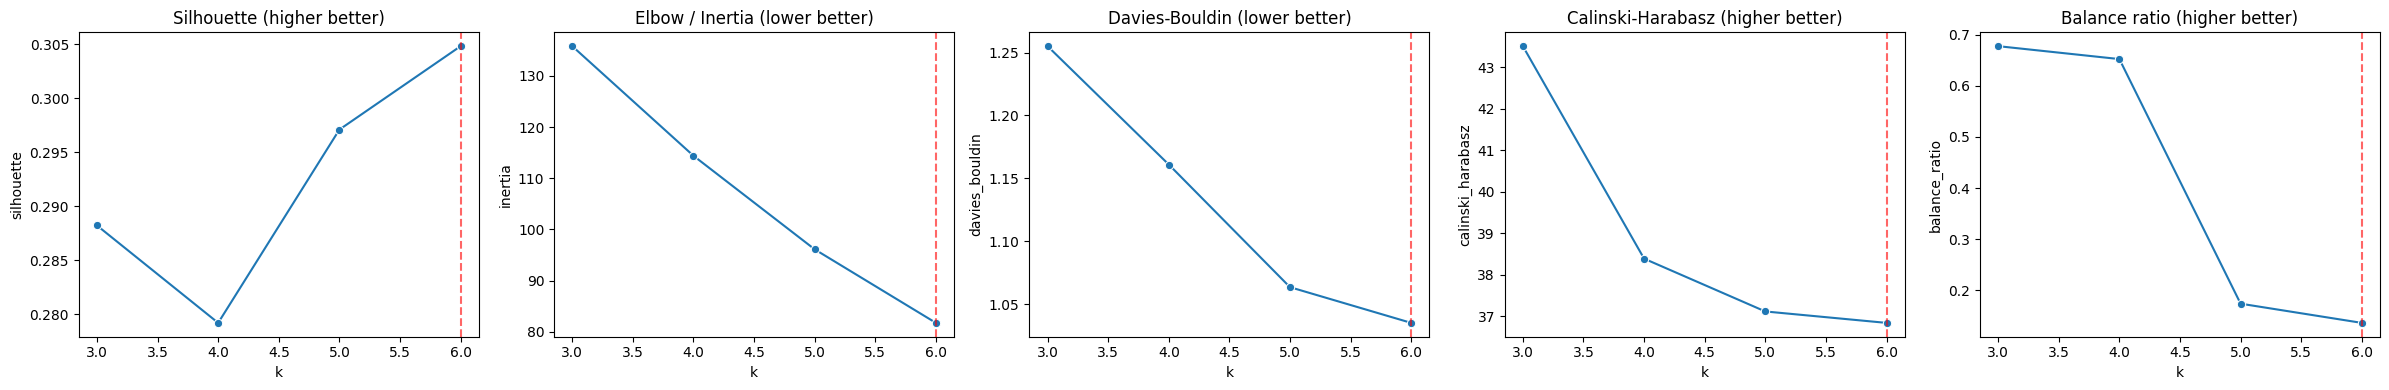

In [36]:
fig, axes = plt.subplots(1, 5, figsize=(24,4))

sns.lineplot(data=eval_df, x="k", y="silhouette", marker="o", ax=axes[0])
axes[0].set_title("Silhouette (higher better)")

sns.lineplot(data=eval_df, x="k", y="inertia", marker="o", ax=axes[1])
axes[1].set_title("Elbow / Inertia (lower better)")

sns.lineplot(data=eval_df, x="k", y="davies_bouldin", marker="o", ax=axes[2])
axes[2].set_title("Davies-Bouldin (lower better)")

sns.lineplot(data=eval_df, x="k", y="calinski_harabasz", marker="o", ax=axes[3])
axes[3].set_title("Calinski-Harabasz (higher better)")

sns.lineplot(data=eval_df, x="k", y="balance_ratio", marker="o", ax=axes[4])
axes[4].set_title("Balance ratio (higher better)")

for ax in axes:
    ax.axvline(best_k, color="red", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## 그래프 해석

### 1) Silhouette (높을수록 좋음)
- k=4에서 잠깐 낮아진 뒤 k=5,6에서 상승
- 분리/응집 관점만 보면 k=6이 가장 좋음

### 2) Elbow / Inertia (낮을수록 좋음)
- k가 증가할수록 꾸준히 감소
- 뚜렷한 단일 elbow는 약하고, 4 이후 개선폭이 완만해지는 경향

### 3) Davies-Bouldin (낮을수록 좋음)
- k 증가에 따라 지속적으로 개선
- k=6이 최저로 가장 유리

### 4) Calinski-Harabasz (높을수록 좋음)
- k=3에서 최고, 이후 하락
- 이 지표 단독으로는 k=3이 유리

### 5) Balance ratio (높을수록 좋음)
- k=3,4는 높고 안정적(약 0.68, 0.65)
- k=5,6에서 급락(약 0.17, 0.14) → 군집 불균형 심화

## 종합 판단
- 성능 지표(분리/응집)만 보면 k=6 쪽이 유리
- 하지만 군집 균형은 k=5,6에서 크게 악화
- **실무 적용(해석 가능성 + 안정성) 기준으로는 k=4가 가장 타협점이 좋음**


### 6) 군집 해석 가능성 검증
- 숫자 지표가 좋아도, 군집 평균 프로필이 서로 구분되지 않으면 실무 해석이 어렵습니다.
- 아래 표에서 k별 군집 평균의 패턴이 명확히 다른지 확인합니다.

In [37]:
for k in k_range:
    print(f"\n--- k={k} 군집 프로필 평균 ---")
    display(profiles[k])


--- k=3 군집 프로필 평균 ---


,환경점수,안전점수,소음점수,교통점수,스시점수
cluster_tmp,,,,,
0,11.98,12.59,17.90,14.91,57.39
1,12.54,18.47,20.00,19.11,70.12
2,14.27,12.77,15.49,13.29,55.83



--- k=4 군집 프로필 평균 ---


,환경점수,안전점수,소음점수,교통점수,스시점수
cluster_tmp,,,,,
0,12.53,18.67,19.95,19.18,70.33
1,12.74,12.88,14.93,13.53,54.09
2,12.03,12.69,19.53,15.57,59.82
3,15.13,12.55,16.26,13.42,57.37



--- k=5 군집 프로필 평균 ---


,환경점수,안전점수,소음점수,교통점수,스시점수
cluster_tmp,,,,,
0,10.47,16.74,23.47,20.01,70.68
1,12.74,12.88,14.93,13.53,54.09
2,13.05,19.15,19.07,18.97,70.24
3,15.13,12.55,16.26,13.42,57.37
4,12.03,12.69,19.53,15.57,59.82



--- k=6 군집 프로필 평균 ---


,환경점수,안전점수,소음점수,교통점수,스시점수
cluster_tmp,,,,,
0,11.76,14.39,18.68,18.40,63.22
1,15.15,12.39,15.61,13.48,56.63
2,10.38,16.95,24.56,20.33,72.22
3,13.26,20.61,18.97,18.82,71.65
4,12.90,12.80,20.48,14.09,60.27
5,12.68,12.92,15.01,13.51,54.12


### 7) 최종 선택 및 적용
- 아래 셀에서 `K_SELECT`만 바꿔 최종 군집에 반영합니다.
- 보통은 추천 k를 기본값으로 두고, 해석이 더 좋은 인접 k(예: 4 vs 5)를 비교합니다.

In [38]:
# 최종 반영용 k (3~6)
K_SELECT = 4   # <- 여기 고정
print("최종 적용 k:", K_SELECT)

best_k = int(K_SELECT)

최종 적용 k: 4


## k=4를 최종 선택한 이유

- 성능지표 기준으로는 k=6이 우수했다.
  - silhouette, davies-bouldin, center distance에서 k=6이 가장 좋았음
- 하지만 k=6은 군집 불균형이 매우 컸다.
  - balance ratio가 크게 낮아(약 0.14) 소수 군집이 과도하게 작아짐
- 본 프로젝트 목적은 “지역 유형 태그를 안정적으로 운영/매핑”하는 것이므로,
  단순 분리 성능보다 군집의 해석 가능성과 운영 안정성이 더 중요하다.
- k=4는 다음을 동시에 만족하는 타협점이다.
  1. 군집 균형이 상대적으로 양호(약 0.65)
  2. 유형 다양성 확보(k=3 대비)
  3. 과도한 쪼개기 방지(k=5,6 대비)

### 결론
- 연구용 성능 최적화 관점: k=6도 타당
- 서비스/정책 적용 관점: k=4가 더 적절
- 따라서 본 분석의 최종 k는 **4**로 채택한다.
